In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error


In [4]:
column_names = [
    'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age',
    'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv'
]

data = pd.read_csv('./datasets/housing.csv', header=None, delimiter=r'\s+', names=column_names)
df = pd.DataFrame(data)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
x = df.drop('medv', axis=1)
y = df['medv']

In [8]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y,
                                              test_size=0.2)

In [9]:
model = LinearRegression()

In [10]:
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.1 , 0.04,-0.02,...,-0.97, 0.01,-0.55]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['crim','zn','indus',...,'ptratio','b','lstat']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,35.12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [11]:
model.score(xtrain, ytrain)

0.7497167351152838

In [12]:
model.score(xtest, ytest)

0.6932914527158986

In [13]:
ptrain = model.predict(xtrain)
ptest = model.predict(xtest)

In [14]:
er_train = mean_absolute_error(ytrain, ptrain)
er_test = mean_absolute_error(ytest, ptest)

In [15]:
er_test

3.6202143848490422

In [16]:
er_train      # distance to real target

3.1547102077534257

In [17]:
ytrain.std()    # distance from mean

np.float64(9.06300191830614)

In [18]:
target = df['medv']

In [19]:
target.mean()

np.float64(22.532806324110677)

In [20]:
target.median()

np.float64(21.2)

In [21]:
target.mode()   # so data isn't Normal (outlier)

0    50.0
Name: medv, dtype: float64

''

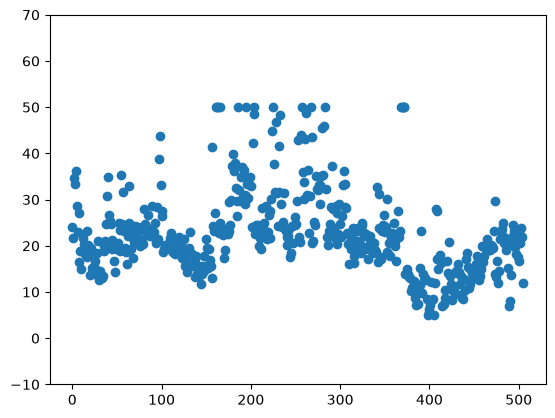

In [ ]:
plt.scatter(np.arange(len(target.values)), target.values)
plt.ylim(bottom=-10, top =70)


/tmp/ipykernel_130995/900599250.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


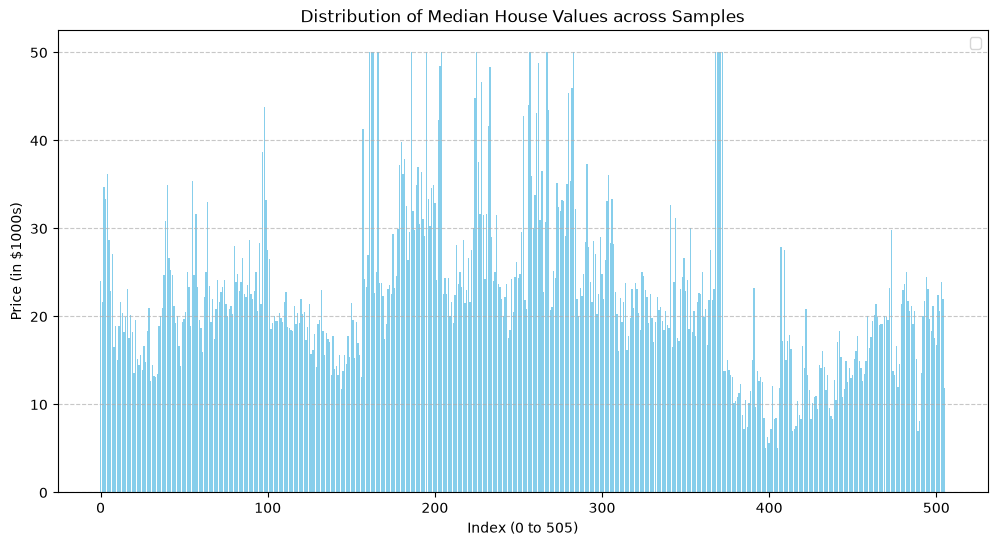

In [23]:
plt.figure(figsize=(12, 6))
plt.bar(np.arange(len(target)), target.values, color='skyblue')
plt.xlabel('Index (0 to 505)')
plt.ylabel('Price (in $1000s)')
plt.title('Distribution of Median House Values across Samples')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

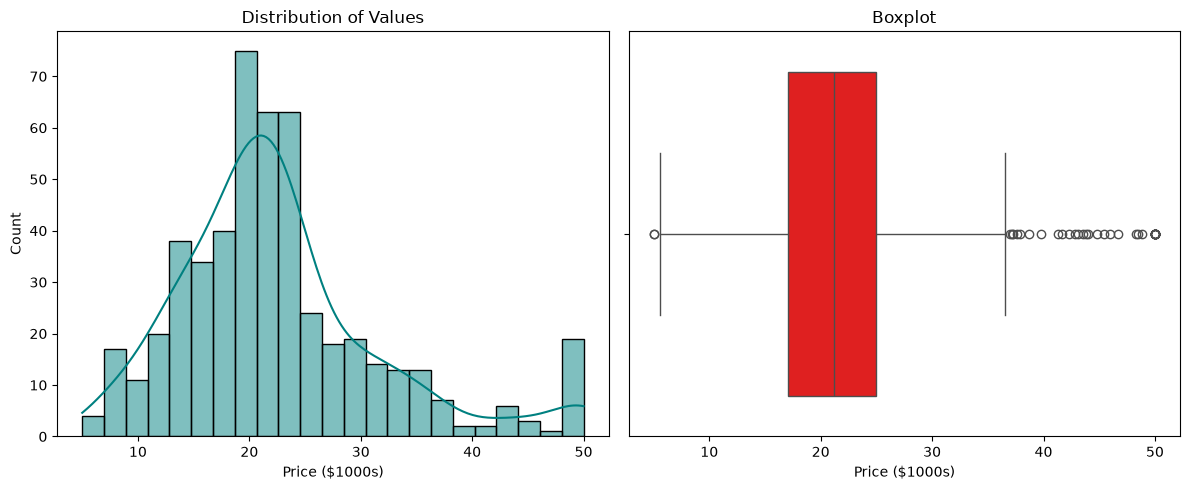

In [24]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(target, kde=True, color='teal')
plt.title('Distribution of Values')
plt.xlabel('Price ($1000s)')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=target, color='red')
plt.title('Boxplot')
plt.xlabel('Price ($1000s)')

plt.tight_layout()
plt.show()

In [25]:
data.corr().round(2)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
zn,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
indus,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
chas,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
nox,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
rm,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
age,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
dis,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
rad,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
tax,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


'      # effects of features on target(medv)'

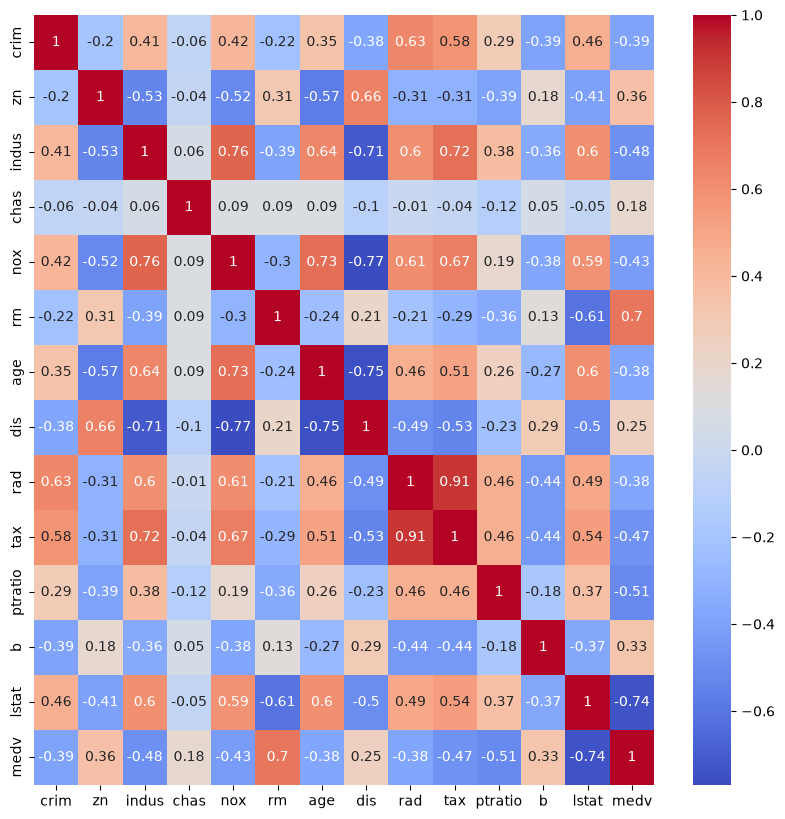

In [26]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr().round(2), annot=True, cmap='coolwarm')
;       # effects of features on target(medv)

''

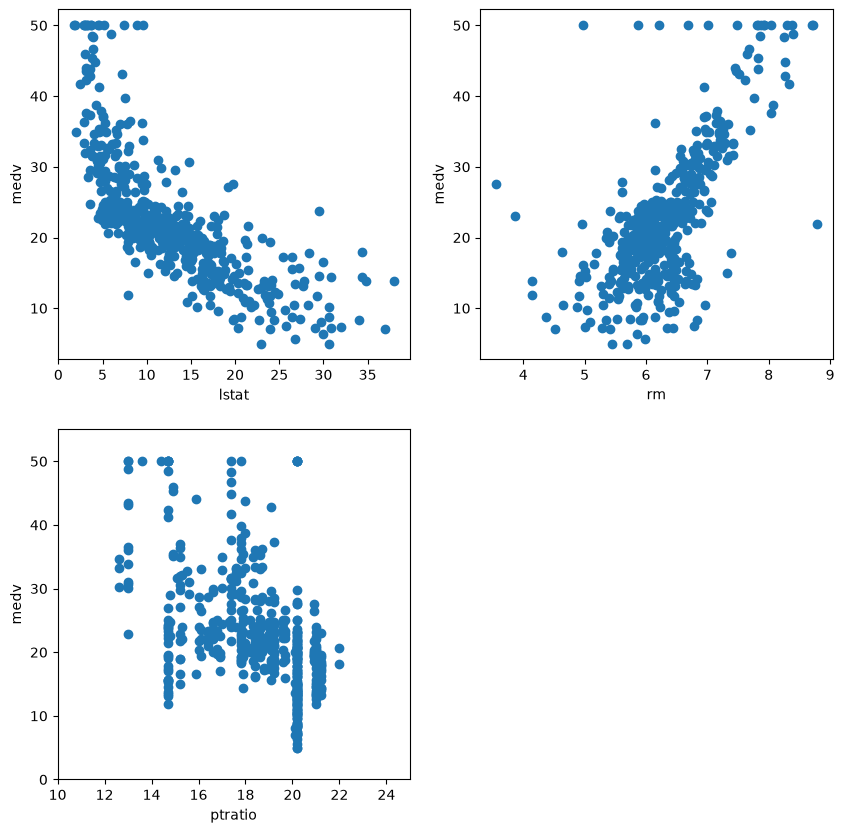

In [27]:
plt.figure(figsize=(10, 10))
plt.subplot(2,2,1)
plt.scatter(x['lstat'], y)
plt.xlabel('lstat')
plt.ylabel('medv')


plt.subplot(2,2,2)
plt.scatter(x['rm'], y)
plt.xlabel('rm')
plt.ylabel('medv')


plt.subplot(2,2,3)
plt.scatter(x['ptratio'], y)
plt.xlim(10, 25)
plt.ylim(0, 55)
plt.xlabel('ptratio')
plt.ylabel('medv')

;

In [28]:
np.where(y==50)

(array([161, 162, 163, 166, 186, 195, 204, 225, 257, 267, 283, 368, 369,
        370, 371, 372]),)

In [29]:
x = x.drop(np.where(y==50)[0])
y = y.drop(np.where(y==50)[0])
print(x.shape)
print(y.shape)

(490, 13)
(490,)


In [30]:
outliers = np.where((y > y.mean() + 3*y.std()) | (y < y.mean() - 3*y.std()))
outliers = y.index[outliers[0]]
outliers

Index([203, 228, 233, 262, 280, 282], dtype='int64')

In [31]:
y.drop(outliers, inplace=True)
x.drop(outliers, inplace=True)
print(y.shape)
print(x.shape)

(484,)
(484, 13)


''

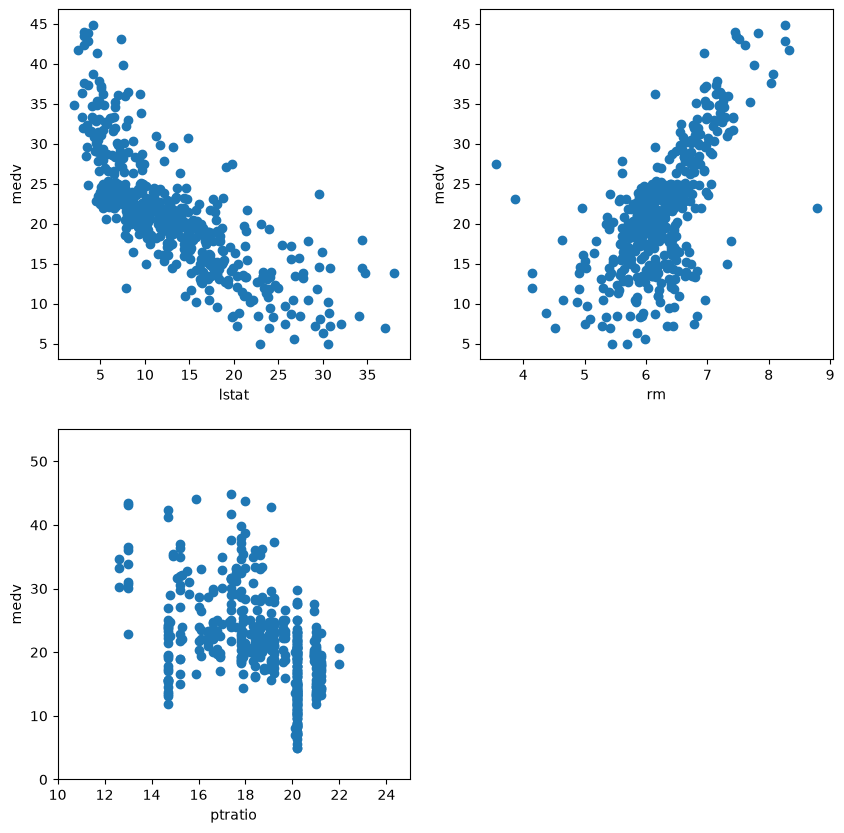

In [32]:
plt.figure(figsize=(10, 10))
plt.subplot(2,2,1)
plt.scatter(x['lstat'], y)
plt.xlabel('lstat')
plt.ylabel('medv')


plt.subplot(2,2,2)
plt.scatter(x['rm'], y)
plt.xlabel('rm')
plt.ylabel('medv')


plt.subplot(2,2,3)
plt.scatter(x['ptratio'], y)
plt.xlim(10, 25)
plt.ylim(0, 55)
plt.xlabel('ptratio')
plt.ylabel('medv')

;

---
---
---

In [33]:
# complex model
x_complex = df.drop(['medv', 'chas', 'dis'], axis=1).values
y_complex = df['medv'].values

In [34]:
xtr_complex, xts_complex, ytr_complex, yts_complex = train_test_split(
                                            x_complex, y_complex, test_size=0.2)

In [35]:
model.fit(xtr_complex, ytr_complex)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[-0.09, 0.01, 0.12,...,-1.11, 0.01,-0.63]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[3620.55,1634.87, 569.83,..., 33.64, 10.25, 1.11]"


In [36]:
model.score(xtr_complex, ytr_complex)

0.6899931396342606

In [37]:
model.score(xts_complex, yts_complex)

0.7532849949713467

In [38]:
ptr_complex = model.predict(xtr_complex)
pts_complex = model.predict(xts_complex)

In [39]:
mean_absolute_error(ytr_complex, ptr_complex)

3.553755910262767

In [40]:
mean_absolute_error(yts_complex, pts_complex)

3.471044620901186

ralation between other features must be check

---
---
---

In [41]:
# simple model

x_simple = df.loc[:, ['lstat', 'rm']]
y_simple = df['medv']

In [42]:
xtr_simple, xts_simple, ytr_simple, yts_simple = train_test_split(
                                            x_simple, y_simple, test_size=0.2)

In [43]:
model.fit(xtr_simple, ytr_simple)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0.6 , 5.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['lstat','rm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.214
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [44]:
model.score(xtr_simple, ytr_simple)

0.6737186225080333

In [45]:
model.score(xts_simple, yts_simple)

0.4949310746826844

In [46]:
ptr_simple = model.predict(xtr_simple)
pts_simple = model.predict(xts_simple)

In [47]:
mean_absolute_error(ytr_simple, ptr_simple)

3.847094764381903

In [48]:
mean_absolute_error(yts_simple, pts_simple)

4.232844717696787

---
---
---

In [49]:
xtr_simple, xts_simple, ytr_simple, yts_simple = train_test_split(
                                    x_simple, y_simple, test_size=0.3, random_state=42)

In [50]:
model = LinearRegression(fit_intercept=False)

In [51]:
poly = PolynomialFeatures(degree=2, include_bias=True)
poly.fit(xtr_simple)
xtr_simple = poly.transform(xtr_simple)

In [52]:
xts_simple = poly.transform(xts_simple)

In [53]:
model.fit(xtr_simple, ytr_simple)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 60.07, -0.04,-13.82, 0.01, -0.19, 1.55]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float,0
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[6055.73, 908.73, 235.27, 21.76, 5.05, 0.19]"


In [54]:
model.score(xtr_simple, ytr_simple)

0.7553107581437002

In [55]:
model.score(xts_simple, yts_simple)

0.7507808550928534

In [56]:
ptr_simple = model.predict(xtr_simple)
pts_simple = model.predict(xts_simple)

In [57]:
mean_absolute_error(ytr_simple, ptr_simple)

3.2243879306222816

In [58]:
mean_absolute_error(yts_simple, pts_simple)

3.1203642075751303